# Phase 6 — Unsupervised Extension

[`walkthrough/phase6.md`](../walkthrough/phase6.md)

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

DATA_PATH = "../dataset/data.csv"
df = pd.read_csv(DATA_PATH)

LEAKAGE_COLS = ["Disposable_Income", "Desired_Savings", "Desired_Savings_Percentage"]
df["Goal_Met"] = (df["Disposable_Income"] >= df["Desired_Savings"]).astype(int)

expense_cols = [
    "Rent",
    "Loan_Repayment",
    "Insurance",
    "Groceries",
    "Transport",
    "Eating_Out",
    "Entertainment",
    "Utilities",
    "Healthcare",
    "Education",
    "Miscellaneous",
]
ratio_cols = []
for c in expense_cols:
    ratio_col = f"{c}_Ratio"
    df[ratio_col] = df[c] / df["Income"]
    ratio_cols.append(ratio_col)

print(f"Shape: {df.shape}")

Shape: (20000, 39)


## Choosing k

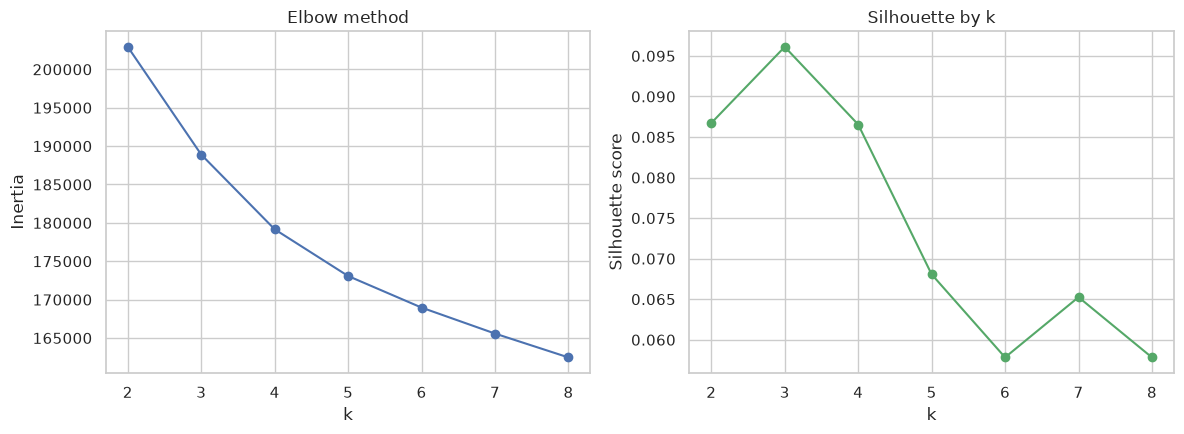

,k,inertia,silhouette
0,2,202929.2492,0.0867
1,3,188895.6852,0.0961
2,4,179164.1608,0.0865
3,5,173078.7117,0.0681
4,6,168964.4505,0.0578
5,7,165581.1578,0.0653
6,8,162471.7764,0.0578


In [2]:
scaler = StandardScaler()
X_ratios = scaler.fit_transform(df[ratio_cols])

k_range = range(2, 9)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_ratios)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_ratios, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")

axes[1].plot(list(k_range), silhouettes, marker="o", color="#55a868")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette by k")
fig.tight_layout()
plt.show()

pd.DataFrame(
    {"k": list(k_range), "inertia": inertias, "silhouette": silhouettes}
).round(4)

## Fitting k=3 and profiling the personas

In [3]:
N_PERSONAS = 3
kmeans = KMeans(n_clusters=N_PERSONAS, n_init=10, random_state=42)
df["Persona"] = kmeans.fit_predict(X_ratios)

persona_sizes = df["Persona"].value_counts().sort_index()
persona_profile = df.groupby("Persona")[ratio_cols].mean().round(4)
persona_profile.insert(0, "n", persona_sizes)
persona_profile

,n,Rent_Ratio,Loan_Repayment_Ratio,Insurance_Ratio,Groceries_Ratio,Transport_Ratio,Eating_Out_Ratio,Entertainment_Ratio,Utilities_Ratio,Healthcare_Ratio,Education_Ratio,Miscellaneous_Ratio
Persona,,,,,,,,,,,,
0,4758,0.3000,0.0501,0.0351,0.1253,0.0650,0.0349,0.0349,0.0600,0.0399,0.0752,0.0201
1,4061,0.2189,0.0491,0.0347,0.1252,0.0653,0.0352,0.0349,0.0601,0.0400,0.0000,0.0200
2,11181,0.1858,0.0501,0.0350,0.1253,0.0649,0.0351,0.0349,0.0603,0.0399,0.0752,0.0200


In [4]:
between_var = (
    pd.DataFrame(X_ratios, columns=ratio_cols)
    .assign(Persona=df["Persona"])
    .groupby("Persona")[ratio_cols]
    .mean()
    .var()
)
total_var = pd.DataFrame(X_ratios, columns=ratio_cols).var()
(between_var / total_var).sort_values(ascending=False).rename(
    "between_persona_variance_share"
).to_frame().head(5)

,between_persona_variance_share
Education_Ratio,1.744548
Rent_Ratio,1.121396
Insurance_Ratio,0.000528
Transport_Ratio,0.000452
Eating_Out_Ratio,0.000312


## Persona composition

In [5]:
persona_context = (
    df.groupby("Persona")
    .agg(
        Dependents=("Dependents", "mean"),
        Zero_Education_Spend_Share=("Education_Ratio", lambda s: (s == 0).mean()),
        Income=("Income", "mean"),
        Age=("Age", "mean"),
    )
    .round(3)
)
persona_context["Dominant_City_Tier"] = df.groupby("Persona")["City_Tier"].agg(
    lambda s: s.value_counts().idxmax()
)
persona_context

,Dependents,Zero_Education_Spend_Share,Income,Age,Dominant_City_Tier
Persona,,,,,
0,2.511,0.0,41126.830,41.081,Tier_1
1,0.000,1.0,41279.940,41.028,Tier_2
2,2.502,0.0,41891.658,41.012,Tier_2


In [6]:
pd.crosstab(df["Persona"], df["City_Tier"])

City_Tier,Tier_1,Tier_2,Tier_3
Persona,,,
0,4758,0,0
1,1176,2069,816
2,0,7999,3182


## Persona vs. `Goal_Met`

In [7]:
persona_goal = pd.crosstab(df["Persona"], df["Goal_Met"])
persona_goal.columns = ["Not met (0)", "Met (1)"]
persona_goal["at_risk_rate"] = (
    persona_goal["Not met (0)"] / persona_goal.sum(axis=1)
).round(4)
persona_goal

,Not met (0),Met (1),at_risk_rate
Persona,,,
0,112,4646,0.0235
1,0,4061,0.0000
2,0,11181,0.0000


In [8]:
chi2, p_value, dof, _ = chi2_contingency(pd.crosstab(df["Persona"], df["Goal_Met"]))
print(f"chi2 = {chi2:.2f}, p = {p_value:.3g}, dof = {dof}")
print(
    f"At-risk individuals by persona: {df.loc[df['Goal_Met'] == 0, 'Persona'].value_counts().to_dict()}"
)

chi2 = 360.81, p = 4.49e-79, dof = 2
At-risk individuals by persona: {0: 112}


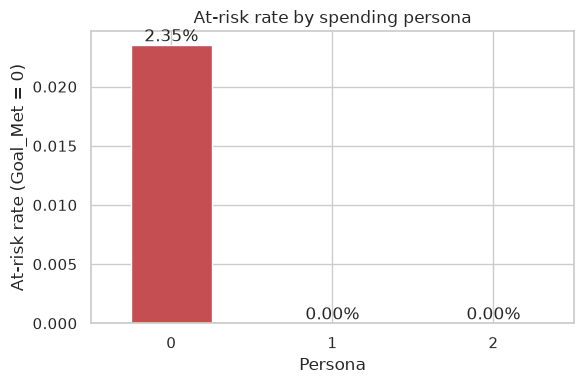

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
persona_goal["at_risk_rate"].plot(
    kind="bar", ax=ax, color=["#c44e52", "#4c72b0", "#4c72b0"], rot=0
)
ax.set_ylabel("At-risk rate (Goal_Met = 0)")
ax.set_xlabel("Persona")
ax.set_title("At-risk rate by spending persona")
for i, v in enumerate(persona_goal["at_risk_rate"]):
    ax.annotate(f"{v:.2%}", (i, v), ha="center", va="bottom")
fig.tight_layout()
plt.show()

## Persisting results

In [10]:
import os

os.makedirs("../results", exist_ok=True)
persona_profile.to_csv("../results/persona_profiles.csv")
fig.savefig("../results/persona_clusters.png", dpi=150)
print("Saved results/persona_profiles.csv and results/persona_clusters.png")

Saved results/persona_profiles.csv and results/persona_clusters.png
